# L=8 workflow demonstration: one chain length, three physical interpretations

This notebook runs the complete HamLeT supervised workflow at chain length **L=8** for the
three registered Heisenberg interpretations:

| Mode | System | View | Targets | Observable |
|---|---|---|---|---|
| `heisenberg/inhomogeneous` | `inhomogeneous_heisenberg` | `local_bonds` | one `J` per bond (7) | `Sz` |
| `heisenberg/xxz_long_range` | `homogeneous_xxz_j1j2j3` | `global` | `J1_xy, J2, J3, Jz` | `total_spin` |
| `heisenberg/xxz_dmi` | `homogeneous_xxz_j1j2j3_dmi` | `global` | `J1_xy, J2, J3, Jz, D_z_magnitude` | `total_spin` |

For each mode it prepares the spectra under one bias cutoff, builds the leakage-safe
supervised view, trains models, and scores them **against known ground truth** on
held-out chains. The inhomogeneous section additionally runs the sliding-window
experimental analyzer on a held-out chain, which is the path a real measurement takes.

**Scale caveat, stated up front.** The datasets shipped with this notebook are small
exact-diagonalization pilots (32-64 chains), sized so the notebook is fast and
reproducible for anyone who clones the repository. They are *not* converged physics, and
the accuracy reached here is far below what the workflow reaches when properly fed: the
project's validated local artifact was trained on 3000 chains, roughly fifty times more
data than the local pilot below. Read every number in this notebook as "how the
machinery behaves and how to read its diagnostics", never as achievable accuracy.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np

from hamlet.data import SpectroscopyDataset, as_supervised
from hamlet.training import (
    TrainingPreprocessingConfig,
    grouped_split,
    prepare_training_dataset,
    train_supervised,
)
from hamlet.training.guided import TrainingPreset

DEMO = "../examples/l8_demo"

# The pilots were generated on a 0-60 meV grid with 61 points, so the whole
# measured window is used and no resampling is needed.
BIAS_CUTOFF_MEV = 60.0
OUTPUT_POINTS = 61

# A three-seed budget with a 50/25/25 chain split. Small datasets need an
# explicit split policy: the built-in presets keep only 10% for test, which
# would leave 3 chains here.
PRESET = TrainingPreset(
    "demo", seeds=(42, 43, 44), epochs=20, batch_size=16, patience=4,
    validation_fraction=0.25, test_fraction=0.25,
)

MODEL_OPTIONS = {
    "ridge": {"alpha": 1e-3},
    "random_forest": {"n_estimators": 300, "min_samples_leaf": 2, "n_jobs": -1},
}

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False})

## 1. The shipped pilot datasets

Each dataset is a compressed `SpectroscopyDataset`: simulated dI/dV-like site maps with
shape `(chains, sites, bias)` plus the exact Hamiltonian parameters that produced them.
The `.generation.json` sidecar next to each file records the full recipe and its
fingerprint, so any of them can be regenerated exactly (see the final section).

In [2]:
DATASETS = {
    "inhomogeneous": f"{DEMO}/inhomogeneous_l8_ed.npz",
    "xxz": f"{DEMO}/homogeneous_xxz_l8_ed.npz",
    "xxz_dmi": f"{DEMO}/homogeneous_xxz_dmi_l8_ed.npz",
}
data = {name: SpectroscopyDataset.load(path) for name, path in DATASETS.items()}

for name, ds in data.items():
    protocol = ds.metadata.get("protocol", {})
    print(f"{name}")
    print(f"  system      : {ds.system_type}")
    print(f"  chains      : {ds.n_samples:3d}   sites: {ds.n_sites}   "
          f"bias: {ds.bias_mev.min():.0f}-{ds.bias_mev.max():.0f} meV "
          f"({ds.bias_mev.size} pts)")
    print(f"  observable  : {protocol.get('observable')}  "
          f"broadening: {protocol.get('broadening_mev')} meV  "
          f"quantity: {protocol.get('output_quantity')}")
    print(f"  targets     : {', '.join(ds.target_names)}")
    lo = ds.targets_mev.min(axis=0)
    hi = ds.targets_mev.max(axis=0)
    print("  ranges [meV]: " + ", ".join(
        f"{n}: {a:.1f}..{b:.1f}" for n, a, b in zip(ds.target_names, lo, hi)))
    print()

inhomogeneous
  system      : inhomogeneous_heisenberg
  chains      :  64   sites: 8   bias: 0-60 meV (61 pts)
  observable  : Sz  broadening: 1.0 meV  quantity: didv
  targets     : J_bond_0, J_bond_1, J_bond_2, J_bond_3, J_bond_4, J_bond_5, J_bond_6
  ranges [meV]: J_bond_0: 30.0..44.8, J_bond_1: 30.0..45.0, J_bond_2: 30.5..44.9, J_bond_3: 30.1..45.0, J_bond_4: 30.2..44.8, J_bond_5: 30.2..44.9, J_bond_6: 30.1..44.7

xxz
  system      : homogeneous_xxz_j1j2j3
  chains      :  32   sites: 8   bias: 0-60 meV (61 pts)
  observable  : total_spin  broadening: 1.0 meV  quantity: didv
  targets     : J1_xy, J2, J3, Jz
  ranges [meV]: J1_xy: 25.3..44.6, J2: -7.6..7.7, J3: -4.9..4.9, Jz: 25.6..44.9

xxz_dmi
  system      : homogeneous_xxz_j1j2j3_dmi
  chains      :  32   sites: 8   bias: 0-60 meV (61 pts)
  observable  : total_spin  broadening: 1.0 meV  quantity: didv
  targets     : J1_xy, J2, J3, Jz, D_z_magnitude
  ranges [meV]: J1_xy: 25.1..44.6, J2: -6.3..7.5, J3: -4.9..5.0, Jz: 25.6..43

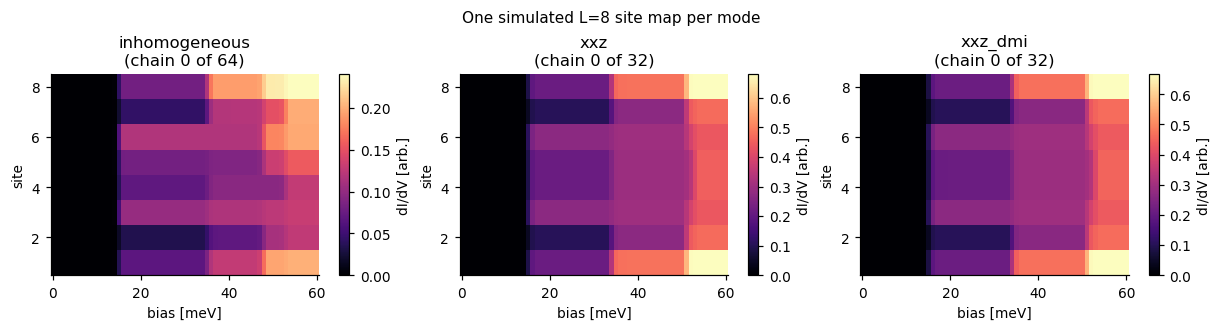

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(11, 2.9), constrained_layout=True)
for ax, (name, ds) in zip(axes, data.items()):
    chain = ds.spectra[0]
    im = ax.pcolormesh(ds.bias_mev, np.arange(1, ds.n_sites + 1), chain,
                       shading="nearest", cmap="magma")
    ax.set(title=f"{name}\n(chain 0 of {ds.n_samples})",
           xlabel="bias [meV]", ylabel="site")
    ax.grid(False)
    fig.colorbar(im, ax=ax, label="dI/dV [arb.]")
fig.suptitle("One simulated L=8 site map per mode", fontsize=10)
plt.show()

## 2. Shared evaluation helpers

Two things are computed for every mode:

- **Test MAE per parameter**, in meV, on chains the model never saw.
- **Skill** against a training-mean baseline: `1 - MAE_model / MAE_mean`. Skill 1.0 is
  perfect, 0.0 means the model is no better than predicting the training average, and
  negative means it is worse than that. This is the honest way to read a small pilot:
  a low MAE on a narrowly-sampled parameter can still carry no information.

In [4]:
def train_mode(dataset, view, model, preset=PRESET):
    # Prepare, train, and return (run, split) for one dataset/view/model.
    prepared = prepare_training_dataset(
        dataset,
        TrainingPreprocessingConfig(
            bias_cutoff_mev=BIAS_CUTOFF_MEV, output_points=OUTPUT_POINTS
        ),
    )
    run = train_supervised(
        prepared, view=view, model=model, preset=preset,
        model_options=MODEL_OPTIONS[model],
    )
    # train_supervised splits internally with the same policy, so recreating the
    # split here reproduces exactly the chains it held out.
    supervised = as_supervised(prepared.dataset, view)
    split = grouped_split(
        supervised,
        validation_fraction=preset.validation_fraction,
        test_fraction=preset.test_fraction,
        seed=preset.split_seed,
    )
    return run, split, prepared


def skill_table(run, split, names):
    # Per-parameter test MAE and skill against a training-mean baseline.
    predicted = run.predict(split.test.inputs)
    baseline = split.train.targets.mean(axis=0)
    rows = []
    for i, name in enumerate(names):
        model_mae = float(np.abs(predicted[:, i] - split.test.targets[:, i]).mean())
        base_mae = float(np.abs(baseline[i] - split.test.targets[:, i]).mean())
        rows.append({"parameter": name, "test_mae_mev": model_mae,
                     "baseline_mae_mev": base_mae,
                     "skill": 1.0 - model_mae / base_mae})
    return rows


def print_skill(title, rows, run, split):
    print(title)
    print(f"  held-out chains: {np.unique(split.test.group_ids).size}"
          f"   examples: {split.test.targets.shape[0]}"
          f"   aggregation: {run.aggregation.method}")
    print(f"  {'parameter':16s}{'test MAE':>10s}{'baseline':>10s}{'skill':>8s}")
    for row in rows:
        print(f"  {row['parameter']:16s}{row['test_mae_mev']:10.3f}"
              f"{row['baseline_mae_mev']:10.3f}{row['skill']:8.2f}")
    print(f"  {'(all targets)':16s}{run.metrics['test']['ensemble']['mae']:10.3f}")
    print()

## 3. Bond-inhomogeneous chain — the local sliding-window view

Every bond gets its own coupling, so the target vector has `L-1 = 7` entries. The model
never sees the whole chain: it consumes **three adjacent site spectra** and predicts the
**two enclosed bonds**. An L=8 chain therefore yields 6 training windows, and the same
trained estimator can be slid over a chain of any length ≥ 3.

The split is grouped by simulated chain, so no window from a test chain appears in
training.

In [5]:
ih = data["inhomogeneous"]
ih_runs = {}
for model in ("ridge", "random_forest"):
    run, split, prepared_ih = train_mode(ih, "local_bonds", model)
    ih_runs[model] = (run, split)
    rows = skill_table(run, split, run.target_names)
    print_skill(f"inhomogeneous / local_bonds / {model}", rows, run, split)

first_run, first_split = ih_runs["ridge"]
print("window inputs :", first_split.train.inputs.shape,
      "(3 sites x 61 bias points, flattened)")
print("window targets:", first_split.train.targets.shape, first_run.target_names)

inhomogeneous / local_bonds / ridge
  held-out chains: 16   examples: 96   aggregation: mean
  parameter         test MAE  baseline   skill
  J_left               4.399     4.122   -0.07
  J_right              5.349     4.046   -0.32
  (all targets)        4.874

inhomogeneous / local_bonds / random_forest
  held-out chains: 16   examples: 96   aggregation: median
  parameter         test MAE  baseline   skill
  J_left               2.775     4.122    0.33
  J_right              2.987     4.046    0.26
  (all targets)        2.881

window inputs : (192, 183) (3 sites x 61 bias points, flattened)
window targets: (192, 2) ('J_left', 'J_right')


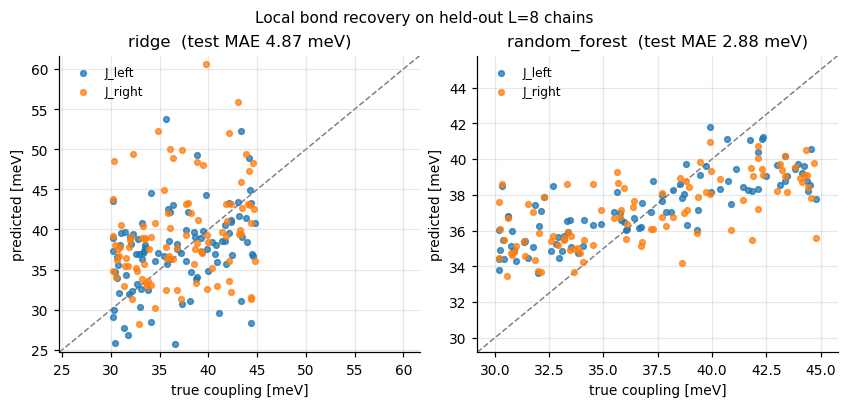

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.6), constrained_layout=True)
for ax, (model, (run, split)) in zip(axes, ih_runs.items()):
    predicted = run.predict(split.test.inputs)
    truth = split.test.targets
    lo = float(min(truth.min(), predicted.min())) - 1
    hi = float(max(truth.max(), predicted.max())) + 1
    ax.plot([lo, hi], [lo, hi], color="0.5", lw=1, ls="--", zorder=1)
    for i, name in enumerate(run.target_names):
        ax.scatter(truth[:, i], predicted[:, i], s=14, alpha=0.75, label=name, zorder=2)
    mae = run.metrics["test"]["ensemble"]["mae"]
    ax.set(title=f"{model}  (test MAE {mae:.2f} meV)",
           xlabel="true coupling [meV]", ylabel="predicted [meV]",
           xlim=(lo, hi), ylim=(lo, hi))
    ax.legend(frameon=False, fontsize=8)
fig.suptitle("Local bond recovery on held-out L=8 chains", fontsize=10)
plt.show()

## 4. Sliding-window inference on a held-out chain

This is the path a real measurement follows. The trained artifact becomes an
`ExperimentalChainAnalyzer`, which applies its own stored preprocessing to a **raw**
site map, slides the three-site estimator along the chain, averages the overlapping
estimates into `L-1` bond values, and reports diagnostics: per-seed ensemble spread,
disagreement between overlapping windows, and whether predictions left the training
distribution.

No cutoff or scaling is supplied here — both come from the artifact, which is what
prevents a model trained at one cutoff being applied to differently prepared data.

The random-forest run is used for this section deliberately. Multi-seed ensembling only
produces spread when the learner is stochastic: ridge has a closed-form solution, so its
three seeds are identical models and its ensemble standard deviation is exactly zero.
A zero spread would therefore mean "this estimator is deterministic", not "this answer is
certain".

Watch the relationship between the reported spread and the actual error below. It is the
clearest single argument for why this package refuses to advertise ensemble spread as a
confidence interval.

In [7]:
run, split = ih_runs["random_forest"]
analyzer = run.create_analyzer()

# Pick a chain the model never saw. group_ids index rows of the dataset.
held_out = int(np.unique(split.test.group_ids)[0])
site_labels = np.arange(1, ih.n_sites + 1)

result = analyzer.analyze(
    ih.spectra[held_out],          # raw, unprocessed site map
    ih.bias_mev,
    source=f"simulated chain {held_out}",
    site_labels=site_labels,
)
truth = ih.targets_mev[held_out]

print(f"held-out chain {held_out}: {result.n_sites} sites -> {result.n_bonds} bonds\n")
print(f"  {'bond':10s}{'true':>8s}{'inferred':>10s}{'ens.std':>9s}{'error':>8s}")
for i, (mean, std) in enumerate(zip(result.coupling_mean, result.coupling_std)):
    print(f"  {f'{site_labels[i]}-{site_labels[i+1]}':10s}{truth[i]:8.2f}"
          f"{mean:10.2f}{std:9.2f}{mean - truth[i]:+8.2f}")
print(f"\n  mean |error|            : {np.abs(result.coupling_mean - truth).mean():.3f} meV")
print(f"  status                  : {result.diagnostics.status}")
print(f"  warnings                : {result.diagnostics.warnings or 'none'}")
print(f"  mean overlap disagreement: {result.diagnostics.mean_overlap_disagreement:.3f} meV")
print(f"  outside training range   : "
      f"{result.diagnostics.fraction_predictions_outside_training_range:.1%}")

held-out chain 5: 8 sites -> 7 bonds

  bond          true  inferred  ens.std   error
  1-2          40.67     41.14     0.09   +0.48
  2-3          36.75     35.64     0.13   -1.11
  3-4          30.81     35.32     0.07   +4.51
  4-5          34.53     37.48     0.23   +2.95
  5-6          39.46     39.47     0.01   +0.01
  6-7          35.49     36.88     0.20   +1.39
  7-8          43.21     39.41     0.26   -3.80

  mean |error|            : 2.036 meV
  status                  : ok
  warnings                : none
  mean overlap disagreement: 1.117 meV
  outside training range   : 0.0%


In [8]:
errors = np.abs(result.coupling_mean - truth)
print(f"mean ensemble std   : {result.coupling_std.mean():.3f} meV")
print(f"mean |actual error| : {errors.mean():.3f} meV")
print(f"ratio               : {errors.mean() / result.coupling_std.mean():.1f}x "
      f"larger than the spread suggests")
print(f"worst bond          : {errors.max():.2f} meV error "
      f"at an ensemble std of {result.coupling_std[errors.argmax()]:.2f} meV")
print(f"reported status     : {result.diagnostics.status}")
print()
print("The seeds agree closely with each other while being jointly wrong: agreement")
print("measures how reproducible this model family is, not how close it is to truth.")
print("A clean status means the input passed its structural and distribution checks,")
print("not that the answer is accurate.")

mean ensemble std   : 0.142 meV
mean |actual error| : 2.036 meV
ratio               : 14.3x larger than the spread suggests
worst bond          : 4.51 meV error at an ensemble std of 0.07 meV
reported status     : ok

The seeds agree closely with each other while being jointly wrong: agreement
measures how reproducible this model family is, not how close it is to truth.
A clean status means the input passed its structural and distribution checks,
not that the answer is accurate.


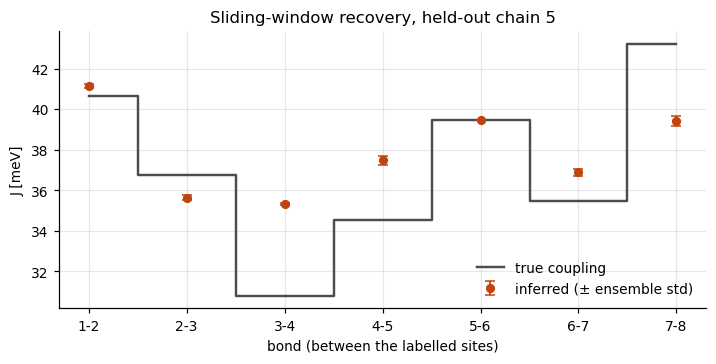

In [9]:
bonds = np.arange(1, result.n_bonds + 1)
fig, ax = plt.subplots(figsize=(6.4, 3.2), constrained_layout=True)
ax.step(bonds, truth, where="mid", color="0.3", lw=1.6, label="true coupling")
ax.errorbar(bonds, result.coupling_mean, yerr=result.coupling_std, fmt="o",
            ms=5, capsize=3, lw=1.2, color="#c1440e", label="inferred (± ensemble std)")
ax.set(xlabel="bond (between the labelled sites)", ylabel="J [meV]",
       title=f"Sliding-window recovery, held-out chain {held_out}",
       xticks=bonds,
       xticklabels=[f"{site_labels[i]}-{site_labels[i+1]}" for i in range(result.n_bonds)])
ax.legend(frameon=False)
plt.show()

## 5. Homogeneous XXZ chain — the global view

Now the whole `(8 x 61)` map is a **single** training example, because the parameters are
properties of the entire chain rather than of individual bonds: `J1_xy` and `Jz` are the
transverse and longitudinal nearest-neighbour couplings, `J2` and `J3` are isotropic
exchange at distance two and three.

Two consequences follow, and both are enforced by the package: a global artifact is only
reusable at the chain length it was trained on, and 32 chains means 32 examples — not
32 x 6 windows as in the local view. This is the fundamental reason the global family
needs far more simulation per unit of statistical power.

In [10]:
xxz = data["xxz"]
xxz_rows = {}
for model in ("ridge", "random_forest"):
    run, split, _ = train_mode(xxz, "global", model)
    rows = skill_table(run, split, run.target_names)
    xxz_rows[model] = rows
    print_skill(f"xxz / global / {model}", rows, run, split)

xxz / global / ridge
  held-out chains: 8   examples: 8   aggregation: mean
  parameter         test MAE  baseline   skill
  J1_xy                3.234     5.148    0.37
  J2                   1.430     2.739    0.48
  J3                   1.160     3.122    0.63
  Jz                   7.872     7.776   -0.01
  (all targets)        3.424

xxz / global / random_forest
  held-out chains: 8   examples: 8   aggregation: validation_weighted
  parameter         test MAE  baseline   skill
  J1_xy                4.537     5.148    0.12
  J2                   3.215     2.739   -0.17
  J3                   2.542     3.122    0.19
  Jz                   7.648     7.776    0.02
  (all targets)        4.485



## 6. Homogeneous XXZ + DMI — five parameters

The same global view with an added uniform nearest-neighbour Dzyaloshinskii–Moriya term
`D_z * (Sx_i Sy_{i+1} - Sy_i Sx_{i+1})`. `D_z` is represented as a **non-negative
magnitude**: unpolarized autocorrelations carry no reliable handedness, so the sign is
deliberately outside the model contract rather than silently invented.

In [11]:
dmi = data["xxz_dmi"]
dmi_rows = {}
for model in ("ridge", "random_forest"):
    run, split, _ = train_mode(dmi, "global", model)
    rows = skill_table(run, split, run.target_names)
    dmi_rows[model] = rows
    print_skill(f"xxz+dmi / global / {model}", rows, run, split)

xxz+dmi / global / ridge
  held-out chains: 8   examples: 8   aggregation: mean
  parameter         test MAE  baseline   skill
  J1_xy                2.242     8.105    0.72
  J2                   2.153     3.898    0.45
  J3                   2.937     2.595   -0.13
  Jz                   3.854     5.224    0.26
  D_z_magnitude        1.396     1.563    0.11
  (all targets)        2.516

xxz+dmi / global / random_forest
  held-out chains: 8   examples: 8   aggregation: median
  parameter         test MAE  baseline   skill
  J1_xy                6.438     8.105    0.21
  J2                   3.027     3.898    0.22
  J3                   2.409     2.595    0.07
  Jz                   5.118     5.224    0.02
  D_z_magnitude        1.591     1.563   -0.02
  (all targets)        3.717



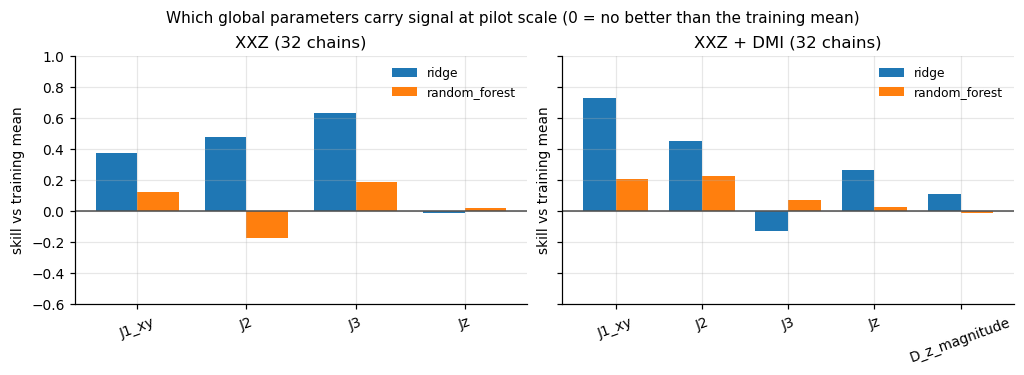

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.3), constrained_layout=True,
                         sharey=True)
for ax, (title, rows_by_model) in zip(
    axes, [("XXZ (32 chains)", xxz_rows), ("XXZ + DMI (32 chains)", dmi_rows)]
):
    names = [r["parameter"] for r in rows_by_model["ridge"]]
    x = np.arange(len(names))
    width = 0.38
    for offset, (model, rows) in zip((-width / 2, width / 2), rows_by_model.items()):
        ax.bar(x + offset, [r["skill"] for r in rows], width, label=model)
    ax.axhline(0.0, color="0.3", lw=1)
    ax.set(title=title, xticks=x, xticklabels=names, ylabel="skill vs training mean")
    ax.tick_params(axis="x", rotation=20)
    ax.legend(frameon=False, fontsize=8)
axes[0].set_ylim(-0.6, 1.0)
fig.suptitle("Which global parameters carry signal at pilot scale "
             "(0 = no better than the training mean)", fontsize=10)
plt.show()

## 7. What this demonstrates — and what it does not

**The workflow runs end to end for all three interpretations of an L=8 chain.** Data
preparation, the leakage-safe grouped split, training, physical-unit scoring against
known ground truth, artifact-based inference from a raw site map, and the diagnostic
reporting all behave as documented. That is what this notebook establishes.

**It does not establish accuracy for any of the three modes.** At pilot scale the
numbers above are weak, and reading them carefully is more instructive than the plots:

- **Model choice dominates.** On local windows, random forest reached a modest skill of
  roughly 0.3 over the training-mean baseline while ridge scored *negative* skill — it
  was worse than predicting the training average. On both global datasets the ranking
  inverts and ridge wins. Neither result is a property of the physics; it is what
  happens when a few dozen chains have to constrain a high-dimensional spectral map.
- **Per-parameter skill is not yet stable.** Between the two global datasets, `J3` swings
  from the best-recovered parameter to worse-than-baseline, and `Jz` moves the other way.
  With 8 held-out chains and a single split, these swings are split noise, not evidence
  about which couplings are physically identifiable. Any claim of the form "this mode
  recovers J3" needs repeated splits and far more chains than are shipped here.
- **The DMI magnitude carries essentially no signal at this scale** (skill near zero for
  both models, with a test MAE comparable to the whole sampled `D_z` range). A number
  the model prints for `D_z` is therefore not evidence of finite DMI. This reproduces
  what the project's earlier DMI screen concluded.
- **Ensemble spread underestimates error badly.** In the inference section the seeds
  agreed to within a few hundredths of a meV on bonds that were wrong by several meV,
  and the run still reported a clean status. Ensemble spread measures reproducibility
  within one model family; it is not a calibrated uncertainty, and the package
  deliberately reports it as "member spread" rather than as an error bar.

**The structural asymmetry between the two views is real, though.** The local view turns
each chain into `L-2` training windows constraining only 2 targets, while the global
views get one example per chain for 4-5 targets. That is a property of the formulation
rather than of this dataset, and it is why the global family needs substantially more
simulation before its per-parameter numbers can mean anything.

Nothing here speaks to whether the simulator matches a real material. Establishing the
homogeneous family properly requires many more simulated chains, repeated splits, and
validation against measurements with independently known parameters — which is exactly
why the project marks the global modes as under test.

## 8. Regenerating the datasets

The shipped pilots came from the package's own checkpointed generator. This is the
recipe for the inhomogeneous set; the two homogeneous sets differ only in the family and
in using `observable="total_spin"` with equal `Sxx`/`Syy`/`Szz` weights.

```python
from hamlet.data import generate_dataset_checkpointed
from hamlet.simulation import DmrgpySimulator, SpectroscopyProtocol
from hamlet.systems import InhomogeneousHeisenbergFamily

family = InhomogeneousHeisenbergFamily(8, (30.0, 45.0))
protocol = SpectroscopyProtocol.uniform(
    (0.0, 60.0), points=61, broadening_mev=1.0,
    observable="Sz", output_quantity="didv",
)
result = generate_dataset_checkpointed(
    family, DmrgpySimulator(dynamics_mode="ED"), protocol,
    n_samples=64, output_path="inhomogeneous_l8_ed.npz",
    recipe=recipe, seed=20260903, checkpoint_every=8,
)
```

`dynamics_mode="ED"` uses exact diagonalization for the dynamical correlators, which is
appropriate and exact at L=8. It is not cheap: on one core this measures roughly
**45 s per chain** for the single `Sz` correlator and **140 s per chain** for
`total_spin`, which evaluates `Sxx`, `Syy`, and `Szz`. That cost, not any software
limit, is why these pilots are small — and generation is checkpointed and
fingerprinted precisely so longer runs can be resumed and reused rather than repeated.